# Deforestation Detection — Model Training & Chip Size Comparison

**Reference:** Das et al., "A Deforestation Detection Network Using Deep Learning-Based Semantic Segmentation" (IEEE Sensors Letters, 2024)

---

## Models
| # | Model | Description |
|---|-------|-------------|
| 1 | UNet | Symmetric U-shaped encoder-decoder |
| 2 | ResNet18-based Modified SegNet | SegNet with ResNet18 encoder |
| 3 | ShuffleNet-based Modified SegNet | SegNet with ShuffleNet encoder |
| 4 | **Proposed Ensemble** | Pixel-wise majority voting of models 1-3 |

## Experiment
Each model is trained on **two chip sizes** (256×256 and 512×512) to compare how patch resolution affects segmentation performance.

**Classes:** 0 = Non-forest, 1 = Forest, 2 = Deforested  
**Metrics:** Recall, Precision, IoU, Dice

---

## 0. Setup & Configuration

In [15]:
import json, gc, time, logging, warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S',
)
log = logging.getLogger(__name__)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.9.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 3080


In [16]:
@dataclass
class TrainConfig:
    data_dir_256: Path = Path("Dataset/Kalsel_Processed_256")
    data_dir_512: Path = Path("Dataset/Kalsel_Processed_512")
    results_dir: Path = Path("Results")
    variant: str = "none"
    composition: str = "NGB"
    num_classes: int = 3
    epochs: int = 10
    batch_size: int = 8
    lr: float = 1e-3
    weight_decay: float = 1e-4
    scheduler_patience: int = 5
    early_stop_patience: int = 10
    seed: int = 42

    @property
    def in_channels(self):
        return {'NGB': 3, 'NDVI': 1, 'EVI': 1}[self.composition]

    @property
    def device(self):
        return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def data_dir(self, chip_size):
        return self.data_dir_256 if chip_size == 256 else self.data_dir_512

    def res_dir(self, chip_size):
        d = self.results_dir / f'{chip_size}px'
        d.mkdir(parents=True, exist_ok=True)
        return d

    def __post_init__(self):
        self.results_dir.mkdir(parents=True, exist_ok=True)

cfg = TrainConfig()
log.info(f'Data 256: {cfg.data_dir_256} | Data 512: {cfg.data_dir_512}')
log.info(f'Variant: {cfg.variant}, Composition: {cfg.composition}')
log.info(f'In channels: {cfg.in_channels}, Classes: {cfg.num_classes}, Device: {cfg.device}')

23:54:52 | INFO | Data 256: Dataset\Kalsel_Processed_256 | Data 512: Dataset\Kalsel_Processed_512
23:54:52 | INFO | Variant: none, Composition: NGB
23:54:52 | INFO | In channels: 3, Classes: 3, Device: cuda


---
## 1. Dataset

In [17]:
class DeforestationDataset(Dataset):
    """Loads preprocessed chips from .npz files.
    If expected_size is set, resizes any chip that doesn't match."""
    def __init__(self, chip_dir, expected_size=None):
        self.files = sorted(Path(chip_dir).glob('*.npz'))
        self.expected_size = expected_size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        image = data['image'].copy()     # (C, H, W)
        mask = data['mask'].copy()        # (H, W)

        # Resize if chip doesn't match expected size
        if self.expected_size and image.shape[-1] != self.expected_size:
            s = self.expected_size
            img_t = torch.from_numpy(image).unsqueeze(0).float()
            image = F.interpolate(img_t, size=(s, s), mode='bilinear', align_corners=False).squeeze(0).numpy()
            msk_t = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0).unsqueeze(0)
            mask = F.interpolate(msk_t, size=(s, s), mode='nearest').squeeze().numpy()

        return {
            'image': torch.from_numpy(image.copy()).float(),
            'mask': torch.from_numpy(mask.copy().astype(np.int64)),
        }


# Verify both datasets
for cs in [256, 512]:
    dp = cfg.data_dir(cs) / cfg.variant / cfg.composition
    log.info(f'\n{cs}px — {dp}')
    for split in ['train', 'val', 'test']:
        sd = dp / split
        n = len(list(sd.glob('*.npz'))) if sd.exists() else 0
        log.info(f'  {split}: {n} chips') if n else log.warning(f'  {split}: NOT FOUND')

23:54:54 | INFO | 
256px — Dataset\Kalsel_Processed_256\none\NGB
23:54:54 | INFO |   train: 11682 chips
23:54:54 | INFO |   val: 3909 chips
23:54:54 | INFO |   test: 3975 chips
23:54:54 | INFO | 
512px — Dataset\Kalsel_Processed_512\none\NGB
23:54:55 | INFO |   train: 11682 chips
23:54:55 | INFO |   val: 3909 chips
23:54:55 | INFO |   test: 3975 chips


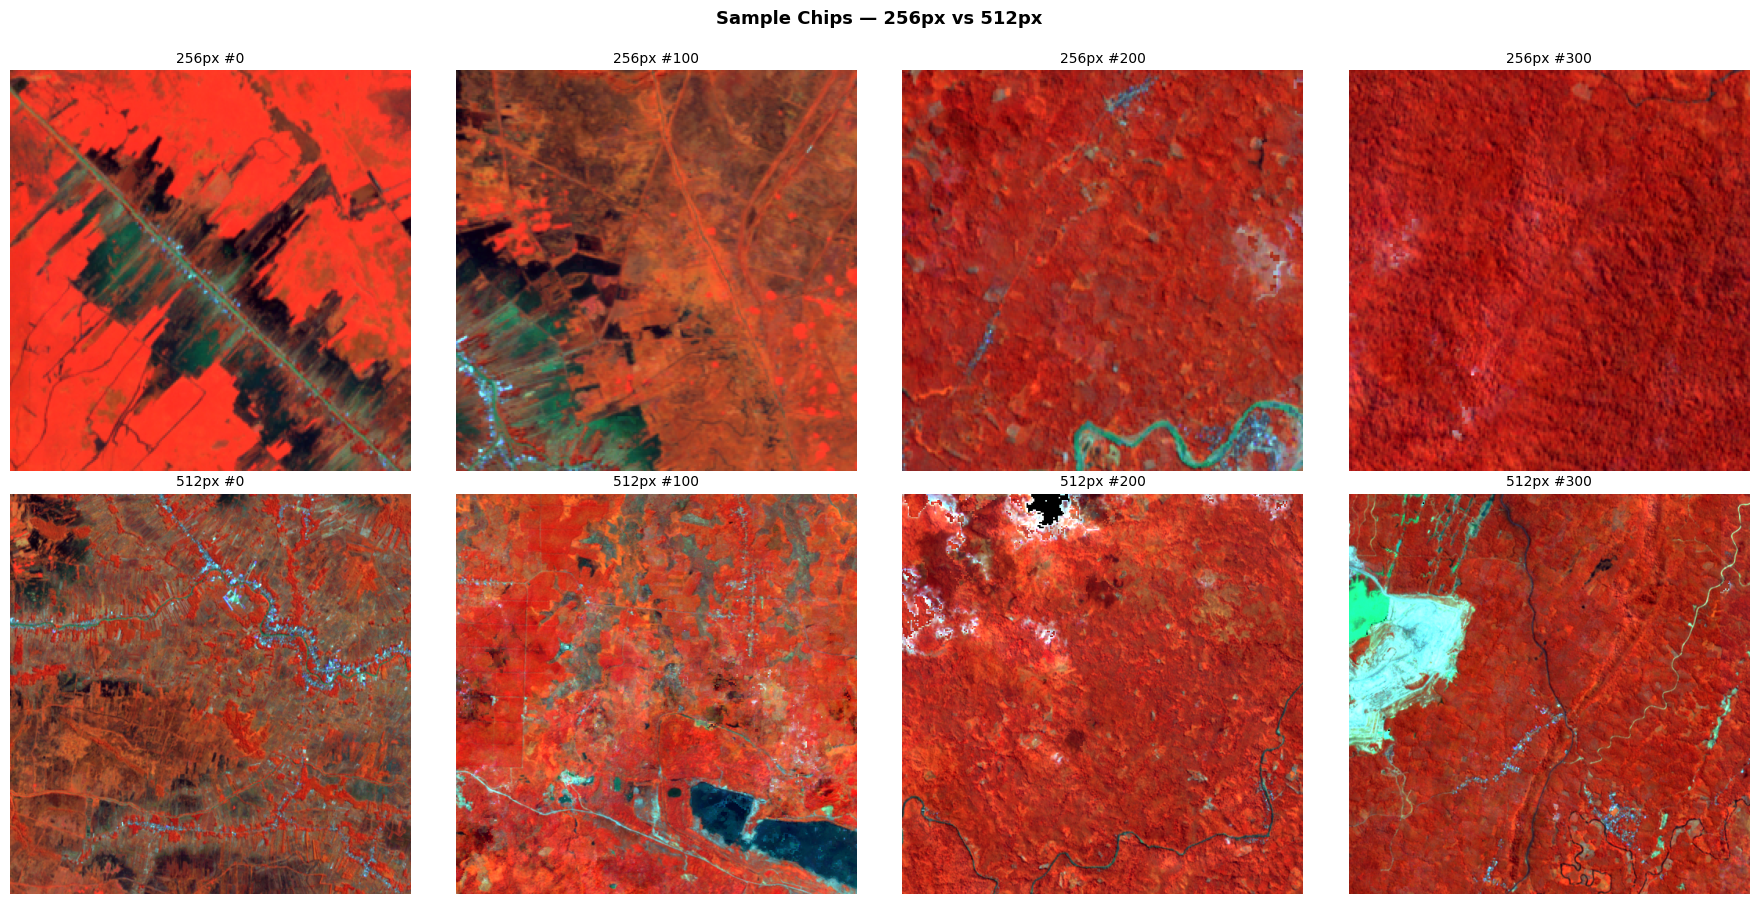

In [18]:
# Sample visualization
from matplotlib.colors import ListedColormap
mask_cmap = ListedColormap(['#808080', '#228B22', '#FF4444'])

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for row, cs in enumerate([256, 512]):
    ds = DeforestationDataset(cfg.data_dir(cs) / cfg.variant / cfg.composition / 'train')
    for col in range(4):
        idx = min(col * 100, len(ds) - 1)
        img = ds[idx]['image'].numpy()
        if img.shape[0] >= 3:
            axes[row, col].imshow(np.clip(img.transpose(1,2,0), 0, 1))
        else:
            axes[row, col].imshow(img[0], cmap='RdYlGn', vmin=0, vmax=1)
        axes[row, col].set_title(f'{cs}px #{idx}', fontsize=10)
        axes[row, col].axis('off')
    del ds
fig.suptitle('Sample Chips — 256px vs 512px', fontsize=13, fontweight='bold', y=1)
plt.tight_layout()
plt.savefig(cfg.results_dir / 'sample_chips.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Model Architectures

### 2.1 UNet

In [19]:
class UNet(nn.Module):
    """
    UNet: Symmetric U-shaped encoder-decoder with skip connections.
    Uses upsampling operators instead of pooling (as noted in the paper, Section II-D).
    Reference: Ronneberger et al., "U-Net: Convolutional Networks for Biomedical
    Image Segmentation"
    """
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        # Contracting path
        self.enc1 = self._double_conv(in_channels, 64)
        self.enc2 = self._double_conv(64, 128)
        self.enc3 = self._double_conv(128, 256)
        self.enc4 = self._double_conv(256, 512)

        # Bottleneck
        self.bottleneck = self._double_conv(512, 1024)

        # Expanding path
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = self._double_conv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = self._double_conv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self._double_conv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self._double_conv(128, 64)

        self.classifier = nn.Conv2d(64, num_classes, 1)
        self.pool = nn.MaxPool2d(2, 2)

    def _double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with skip connections
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.classifier(d1)


print('UNet defined.')

UNet defined.


### 2.2 ResNet18-based Modified SegNet

From the paper (Section II-B): Uses ResNet18 as the encoder instead of VGG16.  
Key advantages: **residual learning** + **skip connections** → faster convergence, avoids vanishing gradients.

In [20]:
class ResidualBlock(nn.Module):
    """Basic residual block with skip connection (ResNet18 style)."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out, inplace=True)


class ResNet18ModifiedSegNet(nn.Module):
    """
    Modified SegNet with ResNet18 encoder (Section II-B).

    Encoder: ResNet18 architecture
      - Conv 7x7/64, stride 2 -> MaxPool 3x3, stride 2
      - 2x ResBlock(64) -> 2x ResBlock(128) -> 2x ResBlock(256) -> 2x ResBlock(512)
    Decoder: SegNet-style with max unpooling indices
      - Upsampling + Conv + BN + ReLU + Softmax

    Advantages (from paper):
    - Residual learning: network learns residual mappings, easier optimization
    - Skip connections: gradient flows through shortcuts, avoids vanishing gradient
    - Converges faster than standard SegNet with VGG16
    """
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        # === Encoder (ResNet18) ===
        # Initial conv: 7x7, 64 filters, stride 2 (as described in paper)
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        # MaxPool 3x3, stride 2
        # Using return_indices for SegNet-style decoder

        # Residual blocks: 2 blocks each of [64, 128, 256, 512]
        self.layer1 = nn.Sequential(ResidualBlock(64, 64), ResidualBlock(64, 64))
        self.layer2 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128))
        self.layer3 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256))
        self.layer4 = nn.Sequential(ResidualBlock(256, 512, stride=2), ResidualBlock(512, 512))

        # === Decoder (SegNet-style) ===
        self.dec4 = self._decoder_block(512, 256)
        self.dec3 = self._decoder_block(256, 128)
        self.dec2 = self._decoder_block(128, 64)
        self.dec1 = self._decoder_block(64, 64)
        self.dec0 = self._decoder_block(64, 64)

        self.classifier = nn.Conv2d(64, num_classes, 1)

    def _decoder_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        input_size = x.shape[2:]

        # Encoder
        x0 = self.initial(x)                    # /2
        x0p, idx0 = F.max_pool2d(x0, 3, 2, 1, return_indices=True)  # /4

        x1 = self.layer1(x0p)                   # /4, 64ch
        x2 = self.layer2(x1)                    # /8, 128ch
        x3 = self.layer3(x2)                    # /16, 256ch
        x4 = self.layer4(x3)                    # /32, 512ch

        # Decoder with upsampling
        d4 = F.interpolate(x4, size=x3.shape[2:], mode='bilinear', align_corners=True)
        d4 = self.dec4(d4)                      # /16, 256ch

        d3 = F.interpolate(d4, size=x2.shape[2:], mode='bilinear', align_corners=True)
        d3 = self.dec3(d3)                      # /8, 128ch

        d2 = F.interpolate(d3, size=x1.shape[2:], mode='bilinear', align_corners=True)
        d2 = self.dec2(d2)                      # /4, 64ch

        d1 = F.max_unpool2d(d2, idx0, 3, 2, 1, output_size=x0.shape)
        d1 = self.dec1(d1)                      # /2, 64ch

        d0 = F.interpolate(d1, size=input_size, mode='bilinear', align_corners=True)
        d0 = self.dec0(d0)                      # /1, 64ch

        return self.classifier(d0)


print('ResNet18-based Modified SegNet defined.')

ResNet18-based Modified SegNet defined.


### 2.3 ShuffleNet-based Modified SegNet

From the paper (Section II-C): Uses ShuffleNet as the encoder.  
Key advantages: **pointwise group convolution** + **channel shuffling** → fewer parameters, computationally efficient.

In [21]:
class ChannelShuffle(nn.Module):
    """Channel shuffle operation (key innovation of ShuffleNet).
    Mixes feature maps across groups after group convolution."""
    def __init__(self, groups):
        super().__init__()
        self.groups = groups

    def forward(self, x):
        b, c, h, w = x.shape
        g = self.groups
        x = x.view(b, g, c // g, h, w)
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        return x.view(b, c, h, w)


class ShuffleUnit(nn.Module):
    """
    ShuffleNet unit: pointwise group conv -> channel shuffle -> depthwise conv -> pointwise group conv.
    Reduces computational cost by factorizing convolutions.
    """
    def __init__(self, in_ch, out_ch, groups=3, stride=1):
        super().__init__()
        mid_ch = out_ch // 4
        self.stride = stride

        # 1x1 group convolution
        self.gconv1 = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 1, groups=groups if in_ch % groups == 0 else 1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
        )
        self.shuffle = ChannelShuffle(groups)

        # 3x3 depthwise convolution
        self.dwconv = nn.Sequential(
            nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
        )

        # 1x1 group convolution
        self.gconv2 = nn.Sequential(
            nn.Conv2d(mid_ch, out_ch, 1, groups=groups if mid_ch % groups == 0 else 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = self.gconv1(x)
        out = self.shuffle(out)
        out = self.dwconv(out)
        out = self.gconv2(out)
        out = out + self.shortcut(x)
        return F.relu(out, inplace=True)


class ShuffleNetModifiedSegNet(nn.Module):
    """
    Modified SegNet with ShuffleNet encoder (Section II-C).

    Encoder: ShuffleNet architecture
      - Group convolutions reduce computation
      - Channel shuffling enables cross-group information flow
    Decoder: SegNet-style with upsampling + convolution

    Advantages (from paper):
    - Pointwise group convolution: reduces parameters
    - Channel shuffling: mixes features across groups
    - Fewer FLOPs while maintaining accuracy
    """
    def __init__(self, in_channels=3, num_classes=3, groups=3):
        super().__init__()

        # === Encoder (ShuffleNet) ===
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, 24, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True),
        )

        # Stage 2: 24 -> 120
        self.stage2 = nn.Sequential(
            ShuffleUnit(24, 120, groups=groups, stride=2),
            ShuffleUnit(120, 120, groups=groups),
            ShuffleUnit(120, 120, groups=groups),
        )
        # Stage 3: 120 -> 240
        self.stage3 = nn.Sequential(
            ShuffleUnit(120, 240, groups=groups, stride=2),
            ShuffleUnit(240, 240, groups=groups),
            ShuffleUnit(240, 240, groups=groups),
        )
        # Stage 4: 240 -> 480
        self.stage4 = nn.Sequential(
            ShuffleUnit(240, 480, groups=groups, stride=2),
            ShuffleUnit(480, 480, groups=groups),
            ShuffleUnit(480, 480, groups=groups),
        )

        # === Decoder (SegNet-style) ===
        self.dec4 = self._decoder_block(480, 240)
        self.dec3 = self._decoder_block(240, 120)
        self.dec2 = self._decoder_block(120, 24)
        self.dec1 = self._decoder_block(24, 24)

        self.classifier = nn.Conv2d(24, num_classes, 1)

    def _decoder_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        input_size = x.shape[2:]

        # Encoder
        x0 = self.initial(x)       # /2, 24ch
        x1 = self.stage2(x0)       # /4, 120ch
        x2 = self.stage3(x1)       # /8, 240ch
        x3 = self.stage4(x2)       # /16, 480ch

        # Decoder
        d3 = F.interpolate(x3, size=x2.shape[2:], mode='bilinear', align_corners=True)
        d3 = self.dec4(d3)         # /8, 240ch

        d2 = F.interpolate(d3, size=x1.shape[2:], mode='bilinear', align_corners=True)
        d2 = self.dec3(d2)         # /4, 120ch

        d1 = F.interpolate(d2, size=x0.shape[2:], mode='bilinear', align_corners=True)
        d1 = self.dec2(d1)         # /2, 24ch

        d0 = F.interpolate(d1, size=input_size, mode='bilinear', align_corners=True)
        d0 = self.dec1(d0)         # /1, 24ch

        return self.classifier(d0)


print('ShuffleNet-based Modified SegNet defined.')

ShuffleNet-based Modified SegNet defined.


### 2.4 Proposed Ensemble (Pixel-wise Majority Voting)

From the paper (Section II): The final predicted output is based on **pixel-wise majority voting** of:
1. UNet
2. ResNet18-based Modified SegNet
3. ShuffleNet-based Modified SegNet

This integrates the advantages of all three models for improved accuracy and robustness.

In [22]:
class ProposedEnsemble(nn.Module):
    """
    Proposed semantic segmentation framework (Section II, Fig. 1).

    Ensembles three models via pixel-wise majority voting:
    1. UNet (symmetric architecture, upsampling operators)
    2. ResNet18-based Modified SegNet (residual learning, skip connections)
    3. ShuffleNet-based Modified SegNet (group conv, channel shuffle)

    The combined benefits improve overall accuracy and robustness.
    """
    def __init__(self, unet, resnet_segnet, shuffle_segnet):
        super().__init__()
        self.unet = unet
        self.resnet_segnet = resnet_segnet
        self.shuffle_segnet = shuffle_segnet

    def forward(self, x):
        """During training, return average logits for differentiable training."""
        out1 = self.unet(x)
        out2 = self.resnet_segnet(x)
        out3 = self.shuffle_segnet(x)
        # Average logits (soft voting for training)
        return (out1 + out2 + out3) / 3.0

    def predict_majority(self, x):
        """
        Pixel-wise majority voting for inference (as described in paper).
        Each model predicts a class per pixel, final = majority vote.
        """
        with torch.no_grad():
            pred1 = self.unet(x).argmax(dim=1)           # (B, H, W)
            pred2 = self.resnet_segnet(x).argmax(dim=1)  # (B, H, W)
            pred3 = self.shuffle_segnet(x).argmax(dim=1) # (B, H, W)

            # Stack predictions and take mode (majority vote)
            stacked = torch.stack([pred1, pred2, pred3], dim=0)  # (3, B, H, W)
            majority = torch.mode(stacked, dim=0).values         # (B, H, W)
        return majority


print('Proposed Ensemble (majority voting) defined.')

Proposed Ensemble (majority voting) defined.


### Model Summary

In [23]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def verify_model(model_class, name, in_ch, n_cls):
    model = model_class(in_channels=in_ch, num_classes=n_cls)
    model.eval()
    x = torch.randn(1, in_ch, 256, 256)
    with torch.no_grad():
        y = model(x)
    params = count_params(model)
    print(f'{name:<35s} | params: {params:>10,} | in: {list(x.shape)} -> out: {list(y.shape)}')
    assert y.shape == (1, n_cls, 256, 256), f'Output shape mismatch: {y.shape}'
    del model, x, y
    return params

print(f'Input channels: {cfg.in_channels}, Classes: {cfg.num_classes}')
print('=' * 90)

models_info = {}
for cls, name in [
    (UNet, 'UNet'),
    (ResNet18ModifiedSegNet, 'ResNet18-Modified SegNet'),
    (ShuffleNetModifiedSegNet, 'ShuffleNet-Modified SegNet'),
]:
    p = verify_model(cls, name, cfg.in_channels, cfg.num_classes)
    models_info[name] = p

# Verify ensemble
unet = UNet(cfg.in_channels, cfg.num_classes)
rn_seg = ResNet18ModifiedSegNet(cfg.in_channels, cfg.num_classes)
sh_seg = ShuffleNetModifiedSegNet(cfg.in_channels, cfg.num_classes)
ensemble = ProposedEnsemble(unet, rn_seg, sh_seg)
ensemble.eval()
x = torch.randn(1, cfg.in_channels, 256, 256)
with torch.no_grad():
    y_avg = ensemble(x)
    y_maj = ensemble.predict_majority(x)
p_ens = count_params(ensemble)
print(f'{"Proposed Ensemble":<35s} | params: {p_ens:>10,} | logits: {list(y_avg.shape)}, majority: {list(y_maj.shape)}')
del unet, rn_seg, sh_seg, ensemble, x
gc.collect()

print('\nAll models verified successfully.')

Input channels: 3, Classes: 3
UNet                                | params: 31,037,763 | in: [1, 3, 256, 256] -> out: [1, 3, 256, 256]
ResNet18-Modified SegNet            | params: 15,972,227 | in: [1, 3, 256, 256] -> out: [1, 3, 256, 256]
ShuffleNet-Modified SegNet          | params:  4,357,233 | in: [1, 3, 256, 256] -> out: [1, 3, 256, 256]
Proposed Ensemble                   | params: 51,367,223 | logits: [1, 3, 256, 256], majority: [1, 256, 256]

All models verified successfully.


---
## 3. Training Infrastructure

Metrics from the paper: **Recall**, **Precision**, **IoU** (Intersection over Union), **Dice** coefficient.  

In [24]:
class SegmentationMetrics:
    """
    Computes per-class and mean metrics matching the paper's Tables 1-3:
    Recall (%), Precision (%), IoU, Dice coefficient.
    """
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        self.tp = np.zeros(self.num_classes)
        self.fp = np.zeros(self.num_classes)
        self.fn = np.zeros(self.num_classes)

    def update(self, pred, target):
        """Update counts. pred and target are (B, H, W) integer tensors."""
        pred = pred.cpu().numpy().flatten()
        target = target.cpu().numpy().flatten()
        for c in range(self.num_classes):
            p = (pred == c)
            t = (target == c)
            self.tp[c] += np.sum(p & t)
            self.fp[c] += np.sum(p & ~t)
            self.fn[c] += np.sum(~p & t)

    def compute(self):
        eps = 1e-7
        recall = self.tp / (self.tp + self.fn + eps)
        precision = self.tp / (self.tp + self.fp + eps)
        iou = self.tp / (self.tp + self.fp + self.fn + eps)
        dice = 2 * self.tp / (2 * self.tp + self.fp + self.fn + eps)

        return {
            'recall_per_class': recall,
            'precision_per_class': precision,
            'iou_per_class': iou,
            'dice_per_class': dice,
            'recall': np.mean(recall) * 100,
            'precision': np.mean(precision) * 100,
            'iou': np.mean(iou),
            'dice': np.mean(dice),
        }


class DiceLoss(nn.Module):
    """Soft Dice loss for segmentation."""
    def __init__(self, num_classes, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = (probs * targets_oh).sum(dims)
        union = probs.sum(dims) + targets_oh.sum(dims)
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    """Cross-entropy + Dice loss."""
    def __init__(self, num_classes, ce_weight=0.5, dice_weight=0.5, class_weights=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss(num_classes)
        self.ce_w = ce_weight
        self.dice_w = dice_weight

    def forward(self, logits, targets):
        return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)


print('Metrics and loss functions defined.')

Metrics and loss functions defined.


In [25]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    n_batches = 0

    for batch in loader:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes, is_ensemble=False):
    model.eval()
    metrics = SegmentationMetrics(num_classes)
    total_loss = 0
    n_batches = 0

    for batch in loader:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        if is_ensemble and hasattr(model, 'predict_majority'):
            # Use majority voting for ensemble evaluation
            preds = model.predict_majority(images)
            # Still compute loss with average logits
            outputs = model(images)
            loss = criterion(outputs, masks)
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            preds = outputs.argmax(dim=1)

        total_loss += loss.item()
        metrics.update(preds, masks)
        n_batches += 1

    results = metrics.compute()
    results['loss'] = total_loss / max(n_batches, 1)
    return results


print('Training functions defined.')

Training functions defined.


In [26]:
def train_model(model_name, model, train_loader, val_loader, cfg, save_dir=None, is_ensemble=False):
    device = cfg.device
    model = model.to(device)
    if save_dir is None:
        save_dir = cfg.results_dir

    class_counts = np.zeros(cfg.num_classes)
    for batch in train_loader:
        masks = batch['mask'].numpy()
        for c in range(cfg.num_classes):
            class_counts[c] += np.sum(masks == c)
        if class_counts.sum() > 1e7: break
    class_weights = 1.0 / (class_counts + 1)
    class_weights = class_weights / class_weights.sum() * cfg.num_classes
    class_weights = torch.FloatTensor(class_weights).to(device)
    log.info(f'  Class weights: {class_weights.cpu().numpy().round(3)}')

    criterion = CombinedLoss(cfg.num_classes, class_weights=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=cfg.scheduler_patience, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
    best_dice, best_metrics, patience_counter = 0, None, 0
    save_path = save_dir / f'{model_name}_best.pth'

    for epoch in range(cfg.epochs):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_results = evaluate(model, val_loader, criterion, device, cfg.num_classes, is_ensemble)
        scheduler.step(val_results['dice'])
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_results['loss'])
        history['val_dice'].append(val_results['dice'])
        history['val_iou'].append(val_results['iou'])
        elapsed = time.time() - t0

        if val_results['dice'] > best_dice:
            best_dice = val_results['dice']
            best_metrics = val_results.copy()
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
            marker = ' *'
        else:
            patience_counter += 1
            marker = ''

        if (epoch + 1) % 5 == 0 or epoch == 0:
            lr = optimizer.param_groups[0]['lr']
            log.info(f'  {model_name} Epoch {epoch+1:>3d}/{cfg.epochs} '
                     f'| train: {train_loss:.4f} | val: {val_results["loss"]:.4f} '
                     f'| Dice: {val_results["dice"]:.4f} | IoU: {val_results["iou"]:.4f} '
                     f'| lr: {lr:.2e} | {elapsed:.1f}s{marker}')

        if patience_counter >= cfg.early_stop_patience:
            log.info(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    log.info(f'  Best Dice: {best_dice:.4f}')
    return model, history, best_metrics

print('Training pipeline defined.')

Training pipeline defined.


---
## 4. Experiment Setup

In [27]:
model_factories = {
    'UNet': lambda: UNet(cfg.in_channels, cfg.num_classes),
    'Modified SegNet (ResNet18)': lambda: ResNet18ModifiedSegNet(cfg.in_channels, cfg.num_classes),
    'Modified SegNet (ShuffleNet)': lambda: ShuffleNetModifiedSegNet(cfg.in_channels, cfg.num_classes),
}

def ensemble_factory():
    return ProposedEnsemble(
        UNet(cfg.in_channels, cfg.num_classes),
        ResNet18ModifiedSegNet(cfg.in_channels, cfg.num_classes),
        ShuffleNetModifiedSegNet(cfg.in_channels, cfg.num_classes))

model_order = ['UNet', 'Modified SegNet (ResNet18)', 'Modified SegNet (ShuffleNet)', 'Proposed Ensemble']

results_all = {256: {}, 512: {}}
test_results_all = {256: {}, 512: {}}
loaders_cache = {}

def load_data(chip_size):
    if chip_size in loaders_cache:
        return loaders_cache[chip_size]
    dp = cfg.data_dir(chip_size) / cfg.variant / cfg.composition
    train_ds = DeforestationDataset(dp / 'train', expected_size=chip_size)
    val_ds   = DeforestationDataset(dp / 'val',   expected_size=chip_size)
    test_ds  = DeforestationDataset(dp / 'test',  expected_size=chip_size)
    # Scale batch size: 512px = 4x pixels per image, so reduce batch to avoid GPU OOM
    bs = cfg.batch_size if chip_size <= 256 else max(2, cfg.batch_size // 4)
    log.info(f'{chip_size}px — batch_size={bs} (base={cfg.batch_size})')
    trl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    vl = DataLoader(val_ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=True)
    tel = DataLoader(test_ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=True)
    log.info(f'{chip_size}px — Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
    loaders_cache[chip_size] = (trl, vl, tel, test_ds)
    return trl, vl, tel, test_ds

def train_single(model_name, chip_size, is_ensemble=False):
    trl, vl, _, _ = load_data(chip_size)
    sd = cfg.res_dir(chip_size)
    log.info(f'\n{"="*70}\nTRAINING: {model_name} @ {chip_size}px\n{"="*70}')
    model = ensemble_factory() if is_ensemble else model_factories[model_name]()
    model, history, metrics = train_model(model_name, model, trl, vl, cfg, save_dir=sd, is_ensemble=is_ensemble)
    results_all[chip_size][model_name] = {'model_name': model_name, 'metrics': metrics, 'history': history}
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()
    log.info(f'{model_name} @ {chip_size}px — Dice: {metrics["dice"]:.4f}, IoU: {metrics["iou"]:.4f}')

print('Experiment helpers defined.')

Experiment helpers defined.


---
## 5. Train — 256×256 Chips

### 5.1 UNet @ 256px

In [14]:
train_single('UNet', 256, is_ensemble=False)

10:45:09 | INFO | 256px — Train: 11682 | Val: 3909 | Test: 3975
10:45:09 | INFO | 
TRAINING: UNet @ 256px
10:45:11 | INFO |   Class weights: [0.07  2.736 0.194]
10:53:03 | INFO |   UNet Epoch   1/10 | train: 0.8422 | val: 0.8193 | Dice: 0.4248 | IoU: 0.3126 | lr: 1.00e-03 | 470.1s *
11:16:15 | INFO |   UNet Epoch   5/10 | train: 0.7918 | val: 0.7807 | Dice: 0.4336 | IoU: 0.3074 | lr: 1.00e-03 | 336.8s
11:43:44 | INFO |   UNet Epoch  10/10 | train: 0.7728 | val: 0.7703 | Dice: 0.4710 | IoU: 0.3460 | lr: 1.00e-03 | 329.2s
11:43:44 | INFO |   Best Dice: 0.4745
11:43:44 | INFO | UNet @ 256px — Dice: 0.4745, IoU: 0.3556


### 5.2 Modified SegNet (ResNet18) @ 256px

In [15]:
train_single('Modified SegNet (ResNet18)', 256, is_ensemble=False)

11:45:20 | INFO | 
TRAINING: Modified SegNet (ResNet18) @ 256px
11:45:21 | INFO |   Class weights: [0.084 2.72  0.196]
11:48:04 | INFO |   Modified SegNet (ResNet18) Epoch   1/10 | train: 0.8674 | val: 0.8524 | Dice: 0.3976 | IoU: 0.2870 | lr: 1.00e-03 | 163.3s *
11:58:06 | INFO |   Modified SegNet (ResNet18) Epoch   5/10 | train: 0.8365 | val: 0.8160 | Dice: 0.4259 | IoU: 0.3042 | lr: 1.00e-03 | 149.8s *
12:10:33 | INFO |   Modified SegNet (ResNet18) Epoch  10/10 | train: 0.8151 | val: 0.8198 | Dice: 0.4496 | IoU: 0.3322 | lr: 1.00e-03 | 149.7s *
12:10:33 | INFO |   Best Dice: 0.4496
12:10:33 | INFO | Modified SegNet (ResNet18) @ 256px — Dice: 0.4496, IoU: 0.3322


### 5.3 Modified SegNet (ShuffleNet) @ 256px

In [16]:
train_single('Modified SegNet (ShuffleNet)', 256, is_ensemble=False)

12:13:55 | INFO | 
TRAINING: Modified SegNet (ShuffleNet) @ 256px
12:13:55 | INFO |   Class weights: [0.058 2.809 0.133]
12:49:01 | INFO |   Modified SegNet (ShuffleNet) Epoch   1/10 | train: 0.8685 | val: 0.8578 | Dice: 0.3988 | IoU: 0.2855 | lr: 1.00e-03 | 2105.5s *
13:16:12 | INFO |   Modified SegNet (ShuffleNet) Epoch   5/10 | train: 0.8045 | val: 0.7816 | Dice: 0.4703 | IoU: 0.3478 | lr: 1.00e-03 | 407.0s *
13:50:51 | INFO |   Modified SegNet (ShuffleNet) Epoch  10/10 | train: 0.7748 | val: 0.7826 | Dice: 0.4322 | IoU: 0.3057 | lr: 1.00e-03 | 418.8s
13:50:51 | INFO |   Best Dice: 0.4845
13:50:51 | INFO | Modified SegNet (ShuffleNet) @ 256px — Dice: 0.4845, IoU: 0.3633


### 5.4 Proposed Ensemble @ 256px

In [17]:
train_single('Proposed Ensemble', 256, is_ensemble=True)

13:52:12 | INFO | 
TRAINING: Proposed Ensemble @ 256px
13:52:13 | INFO |   Class weights: [0.066 2.757 0.176]
14:18:54 | INFO |   Proposed Ensemble Epoch   1/10 | train: 0.8418 | val: 0.8217 | Dice: 0.3843 | IoU: 0.2642 | lr: 1.00e-03 | 1601.5s *
16:05:55 | INFO |   Proposed Ensemble Epoch   5/10 | train: 0.7822 | val: 0.8027 | Dice: 0.4246 | IoU: 0.3098 | lr: 1.00e-03 | 1621.5s *
18:19:49 | INFO |   Proposed Ensemble Epoch  10/10 | train: 0.7626 | val: 0.7598 | Dice: 0.4059 | IoU: 0.2822 | lr: 1.00e-03 | 1598.0s
18:19:49 | INFO |   Best Dice: 0.4246
18:19:50 | INFO | Proposed Ensemble @ 256px — Dice: 0.4246, IoU: 0.3098


---
## 6. Train — 512×512 Chips

### 6.1 UNet @ 512px

In [ ]:
train_single('UNet', 512, is_ensemble=False)

23:57:50 | INFO | 512px — Train: 11682 | Val: 3909 | Test: 3975
23:57:50 | INFO | 
TRAINING: UNet @ 512px
23:57:51 | INFO |   Class weights: [0.038 2.861 0.101]


### 6.2 Modified SegNet (ResNet18) @ 512px

In [ ]:
train_single('Modified SegNet (ResNet18)', 512, is_ensemble=False)

### 6.3 Modified SegNet (ShuffleNet) @ 512px

In [ ]:
train_single('Modified SegNet (ShuffleNet)', 512, is_ensemble=False)

### 6.4 Proposed Ensemble @ 512px

In [ ]:
train_single('Proposed Ensemble', 512, is_ensemble=True)

---
## 7. Results & Chip Size Comparison

In [ ]:
# Evaluate on TEST set for both chip sizes
dummy_criterion = CombinedLoss(cfg.num_classes)
for cs in [256, 512]:
    _, _, tel, _ = load_data(cs)
    sd = cfg.res_dir(cs)
    for name in model_order:
        if name not in results_all[cs]: continue
        path = sd / f'{name}_best.pth'
        if not path.exists(): continue
        is_ens = (name == 'Proposed Ensemble')
        m = ensemble_factory() if is_ens else model_factories[name]()
        m.load_state_dict(torch.load(path, weights_only=True, map_location=cfg.device))
        m.to(cfg.device).eval()
        test_results_all[cs][name] = evaluate(m, tel, dummy_criterion, cfg.device, cfg.num_classes, is_ens)
        del m
    gc.collect()
    log.info(f'{cs}px test evaluation done.')

In [ ]:
# === Comparison Tables ===
def print_comparison(title, get_m):
    print(f'\n{"="*100}')
    print(title)
    print(f'{"="*100}')
    print(f'{"Methods":<30s} | {"--- 256px ---":^35s} | {"--- 512px ---":^35s}')
    print(f'{"":30s} | {"Recall":>8s} {"Prec":>8s} {"IoU":>8s} {"Dice":>8s} '
          f'| {"Recall":>8s} {"Prec":>8s} {"IoU":>8s} {"Dice":>8s}')
    print('-' * 100)
    for name in model_order:
        row = f'{name:<30s} |'
        for cs in [256, 512]:
            m = get_m(cs, name)
            if m:
                row += f' {m["recall"]:>7.2f}% {m["precision"]:>7.2f}% {m["iou"]:>7.4f} {m["dice"]:>7.4f} |'
            else:
                row += f'{"  —":>37s} |'
        print(row)
    print('=' * 100)

print_comparison('Validation: 256px vs 512px',
    lambda cs, n: results_all[cs][n]['metrics'] if n in results_all[cs] else None)
print_comparison('Test: 256px vs 512px',
    lambda cs, n: test_results_all[cs].get(n))

In [ ]:
# === Training Curves ===
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
colors = plt.cm.Set2(np.linspace(0, 1, len(model_order)))
for row, cs in enumerate([256, 512]):
    for i, name in enumerate(model_order):
        if name not in results_all[cs]: continue
        h = results_all[cs][name]['history']
        axes[row,0].plot(h['train_loss'], color=colors[i], label=name, lw=1.5)
        axes[row,1].plot(h['val_loss'], color=colors[i], label=name, lw=1.5)
        axes[row,2].plot(h['val_dice'], color=colors[i], label=name, lw=1.5)
        axes[row,3].plot(h['val_iou'], color=colors[i], label=name, lw=1.5)
    for j, (t, yl) in enumerate([('Train Loss','Loss'),('Val Loss','Loss'),('Val Dice','Dice'),('Val IoU','IoU')]):
        axes[row,j].set_title(f'{cs}px — {t}', fontweight='bold')
        axes[row,j].set_xlabel('Epoch'); axes[row,j].set_ylabel(yl)
        axes[row,j].legend(fontsize=7); axes[row,j].grid(True, alpha=0.3)
fig.suptitle('Training Curves — 256px vs 512px', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(cfg.results_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# === Bar Chart: Dice & IoU ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
short = [n.replace('Modified SegNet','M-SegNet').replace('Proposed Ensemble','Proposed') for n in model_order]
x = np.arange(len(model_order)); w = 0.35
for ax, metric, title in [(axes[0],'dice','Dice'),(axes[1],'iou','IoU')]:
    v256 = [test_results_all[256][n][metric] if n in test_results_all[256] else 0 for n in model_order]
    v512 = [test_results_all[512][n][metric] if n in test_results_all[512] else 0 for n in model_order]
    b1 = ax.bar(x-w/2, v256, w, label='256×256', color='#3498db', alpha=0.85)
    b2 = ax.bar(x+w/2, v512, w, label='512×512', color='#e74c3c', alpha=0.85)
    ax.bar_label(b1, fmt='%.3f', fontsize=7, padding=2)
    ax.bar_label(b2, fmt='%.3f', fontsize=7, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(short, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Test {title}: 256 vs 512', fontweight='bold')
    ax.set_ylabel(title); ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(cfg.results_dir / 'chip_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Qualitative Results

Paper Figs. 2-3 style: **(a)** Original → **(b)** Ground Truth → **(c-f)** Model predictions.  
One figure per chip size, plus a side-by-side chip-size comparison.

In [ ]:
def qualitative_paper_style(chip_size, n_samples=4):
    """Paper Figs. 2-3 style grid: rows=samples, cols=Original|GT|models."""
    device = cfg.device
    _, _, _, test_ds = load_data(chip_size)
    sd = cfg.res_dir(chip_size)
    np.random.seed(cfg.seed)
    indices = np.random.choice(len(test_ds), min(n_samples, len(test_ds)), replace=False)

    loaded = {}
    for name in model_order:
        path = sd / f'{name}_best.pth'
        if not path.exists(): continue
        is_ens = (name == 'Proposed Ensemble')
        m = ensemble_factory() if is_ens else model_factories[name]()
        m.load_state_dict(torch.load(path, weights_only=True, map_location=device))
        m.to(device).eval()
        loaded[name] = (m, is_ens)

    show = [n for n in model_order if n in loaded]
    n_cols = 2 + len(show)
    labels = ['(a) Original', '(b) Ground Truth'] + \
             [f'({chr(99+j)}) {n.replace("Modified SegNet","M-SegNet")}' for j, n in enumerate(show)]

    fig, axes = plt.subplots(n_samples, n_cols, figsize=(3.2*n_cols, 3.2*n_samples))
    if n_samples == 1: axes = axes.reshape(1, -1)

    for i, idx in enumerate(indices):
        s = test_ds[idx]
        img, mask = s['image'], s['mask']
        ax = axes[i, 0]
        if img.shape[0]>=3: ax.imshow(np.clip(img.numpy().transpose(1,2,0),0,1))
        else: ax.imshow(img[0].numpy(), cmap='RdYlGn', vmin=0, vmax=1)
        ax.axis('off')
        axes[i,1].imshow(mask.numpy(), cmap=mask_cmap, vmin=0, vmax=2, interpolation='nearest')
        axes[i,1].axis('off')

        inp = img.unsqueeze(0).to(device)
        for j, name in enumerate(show):
            m, is_ens = loaded[name]
            with torch.no_grad():
                pred = m.predict_majority(inp).squeeze(0) if is_ens else m(inp).argmax(1).squeeze(0)
            axes[i,2+j].imshow(pred.cpu().numpy(), cmap=mask_cmap, vmin=0, vmax=2, interpolation='nearest')
            axes[i,2+j].axis('off')

    for j, l in enumerate(labels):
        axes[0,j].set_title(l, fontsize=9, fontweight='bold')

    fig.suptitle(f'Qualitative Comparison — {chip_size}×{chip_size}px', fontsize=14, fontweight='bold')
    fig.text(0.5, -0.01, 'Gray=Non-forest | Green=Forest | Red=Deforested', ha='center', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(cfg.results_dir / f'qualitative_{chip_size}px.png', dpi=150, bbox_inches='tight')
    plt.show()
    for m, _ in loaded.values(): del m
    del loaded; gc.collect()

qualitative_paper_style(256)
qualitative_paper_style(512)

In [ ]:
def chipsize_side_by_side(n_samples=3):
    """Same model's predictions at 256 vs 512, side by side."""
    device = cfg.device
    best_name = 'Proposed Ensemble'
    if best_name not in results_all[256] and best_name not in results_all[512]:
        avail = set(results_all[256]) | set(results_all[512])
        best_name = max(avail, key=lambda n:
            max(results_all[256].get(n,{}).get('metrics',{}).get('dice',0),
                results_all[512].get(n,{}).get('metrics',{}).get('dice',0)))

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    if n_samples == 1: axes = axes.reshape(1, -1)
    titles = ['256px Input', '256px Prediction', '512px Input', '512px Prediction']

    for ci, cs in enumerate([256, 512]):
        _, _, _, test_ds = load_data(cs)
        path = cfg.res_dir(cs) / f'{best_name}_best.pth'
        if not path.exists(): continue
        is_ens = (best_name == 'Proposed Ensemble')
        m = ensemble_factory() if is_ens else model_factories[best_name]()
        m.load_state_dict(torch.load(path, weights_only=True, map_location=device))
        m.to(device).eval()
        np.random.seed(cfg.seed)
        indices = np.random.choice(len(test_ds), min(n_samples, len(test_ds)), replace=False)
        for i, idx in enumerate(indices):
            img = test_ds[idx]['image']
            c_img, c_pred = ci*2, ci*2+1
            if img.shape[0]>=3: axes[i,c_img].imshow(np.clip(img.numpy().transpose(1,2,0),0,1))
            else: axes[i,c_img].imshow(img[0].numpy(), cmap='RdYlGn')
            axes[i,c_img].axis('off')
            with torch.no_grad():
                inp = img.unsqueeze(0).to(device)
                pred = m.predict_majority(inp).squeeze(0) if is_ens else m(inp).argmax(1).squeeze(0)
            axes[i,c_pred].imshow(pred.cpu().numpy(), cmap=mask_cmap, vmin=0, vmax=2, interpolation='nearest')
            axes[i,c_pred].axis('off')
        del m
    for j, t in enumerate(titles): axes[0,j].set_title(t, fontsize=10, fontweight='bold')
    fig.suptitle(f'Chip Size Effect — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(cfg.results_dir / 'chipsize_side_by_side.png', dpi=150, bbox_inches='tight')
    plt.show(); gc.collect()

chipsize_side_by_side()

---
## 9. Save Results

In [ ]:
summary = {'config': {'variant': cfg.variant, 'composition': cfg.composition,
    'epochs': cfg.epochs, 'batch_size': cfg.batch_size, 'lr': cfg.lr}, 'chip_sizes': {}}
for cs in [256, 512]:
    cs_e = {}
    for name in model_order:
        e = {}
        if name in results_all[cs]:
            e['val'] = {k: float(v) for k,v in results_all[cs][name]['metrics'].items() if k in ['recall','precision','iou','dice','loss']}
        if name in test_results_all[cs]:
            e['test'] = {k: float(v) for k,v in test_results_all[cs][name].items() if k in ['recall','precision','iou','dice','loss']}
        if e: cs_e[name] = e
    summary['chip_sizes'][str(cs)] = cs_e
with open(cfg.results_dir / 'experiment_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\n' + '='*70 + '\nEXPERIMENT COMPLETE\n' + '='*70)
print(f'Variant: {cfg.variant}/{cfg.composition} | Epochs: {cfg.epochs}')
for cs in [256, 512]:
    if test_results_all[cs]:
        best = max(test_results_all[cs], key=lambda n: test_results_all[cs][n]['dice'])
        print(f'{cs}px best: {best} (Dice={test_results_all[cs][best]["dice"]:.4f})')
print(f'Results: {cfg.results_dir}/')
print('='*70)